# Determine Exposure Meter Zero Points

Each observation can be used as a measure of the zero point of the exposure meter.  By examining the distribution of these zero point values, we can try to determine the nominal zero point -- the zero point we would achieve under nominal (i.e. good) conditions.  We'll take the 90th percentile of the distribution as "nominal" for this calculation.

In [1]:
from pathlib import Path
import yaml
import numpy as np
from astropy import stats
from astropy.time import Time
from astropy.table import Table, MaskedColumn
from kpf_etc.etc import kpf_photon_noise_estimate

import matplotlib.pyplot as plt

data_file = 'data/Feb2026_anonymized.csv'
t = Table.read(data_file, format='ascii.csv')

In [2]:
# KPFERA 1.0 is before SM1
SM1start = Time('2024-02-03')
SM1end = Time('2024-02-23')
# KPFERA 2.0 is between SM1 and SM2
SM2start = Time('2024-10-31')
SM2end = Time('2024-11-20')
# KPFERA 2.5/2.6 is between SM2 and SM3
SM3start = Time('2025-03-28')
SM3end = Time('2025-04-23')
# KPFERA 3.0 is between SM3 and SM4
SM4start = Time('2025-08-31')
SM4end = Time('2025-10-27')
# KPFERA 4.0 is after SM4

In [3]:
def Nmasked(t, column='TOTCORR'):
    mask_count = int(np.sum(np.array(t[column].mask, dtype=int)))
    print(f"{mask_count} masked out of {len(t)} for {column}")

In [4]:
Nmasked(t)

2004 masked out of 12058 for TOTCORR


In [5]:
# Mask out negative exposure meter flux
t['TOTCORR'].mask = t['TOTCORR'].mask | (t['TOTCORR_SUM'] <= 0).data
Nmasked(t)

3651 masked out of 12058 for TOTCORR


In [6]:
# Mask out exposure meter data from before reformatter realignment
t['TOTCORR'].mask = t['TOTCORR'].mask | (t['MJD-OBS'] < SM1end.mjd).data
Nmasked(t)

4709 masked out of 12058 for TOTCORR


In [7]:
for EMbin in [1, 2, 3, 4, 'SUM']:
    t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_{EMbin}'] / t['EXPTIME']), name=f'EMZP_{EMbin}'))
    t[f'TOTCORR_{EMbin}'].mask = t['TOTCORR'].mask | t[f'TOTCORR_{EMbin}'].mask | (t[f'TOTCORR_{EMbin}'] <= 0)
    t[f'EMZP_{EMbin}'].mask = t[f'TOTCORR_{EMbin}'].mask
    Nmasked(t, column=f'TOTCORR_{EMbin}')
    Nmasked(t, column=f'EMZP_{EMbin}')


4712 masked out of 12058 for TOTCORR_1
4712 masked out of 12058 for EMZP_1
4709 masked out of 12058 for TOTCORR_2
4709 masked out of 12058 for EMZP_2
4710 masked out of 12058 for TOTCORR_3
4710 masked out of 12058 for EMZP_3
4710 masked out of 12058 for TOTCORR_4
4710 masked out of 12058 for EMZP_4
4709 masked out of 12058 for TOTCORR_SUM
4709 masked out of 12058 for EMZP_SUM


/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_46210/3329158793.py:2: RuntimeWarning: divide by zero encountered in log10
  t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_{EMbin}'] / t['EXPTIME']), name=f'EMZP_{EMbin}'))
/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_46210/3329158793.py:2: RuntimeWarning: invalid value encountered in log10
  t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_{EMbin}'] / t['EXPTIME']), name=f'EMZP_{EMbin}'))


In [8]:
def calculate_ExpMeter_zero_point(t, EMbin=1, percentile=90, plot=False):
    mask = t[f'EMZP_{EMbin}'].mask
    EMZP = float(np.percentile(t[f'EMZP_{EMbin}'][~mask], percentile))
    # print(f"Exposure Meter Zero Point = {EMZP:.2f}")

    if plot:
        plt.figure(figsize=(10,3))
        plt.title(f'Exposure Meter Zero Point (bin {EMbin}) = {EMZP:.2f}')
        plt.hist(t[f'EMZP_{EMbin}'][~mask], bins=200, density=True, label='Zero Points')
        plt.ylabel(f'Density (N={len(t[~mask])})')
        plt.axvline(EMZP, color='k', alpha=0.5, label='Nominal Zero Point')
        plt.grid()
        plt.legend(loc='best')
        plt.xlim(12,24)
        plt.xlabel('Zero Point (mag)')
        plt.show()

    return EMZP

/Users/jwalawender/miniforge3/envs/py313/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


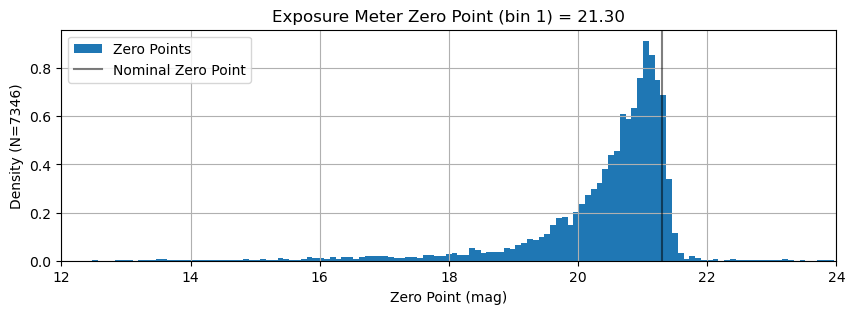

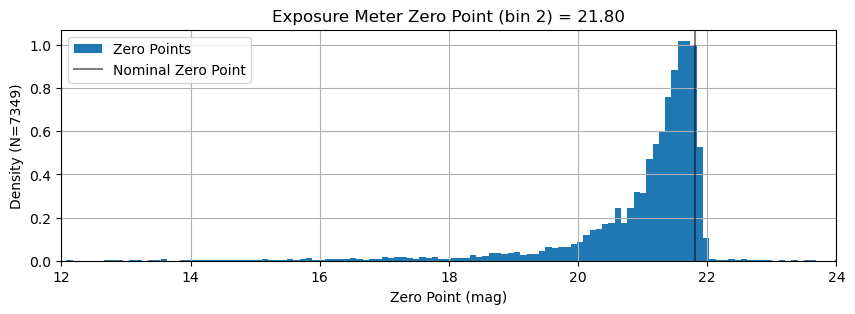

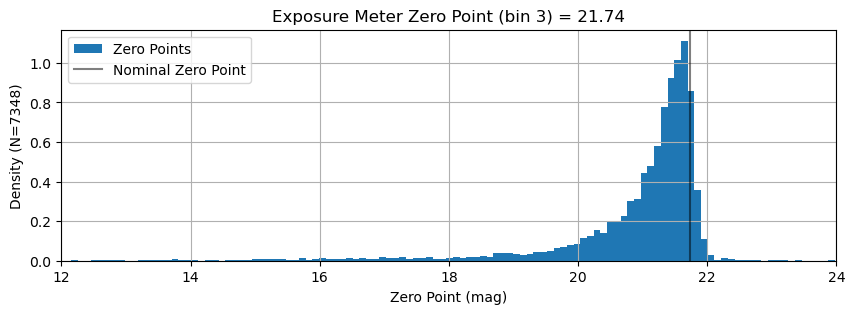

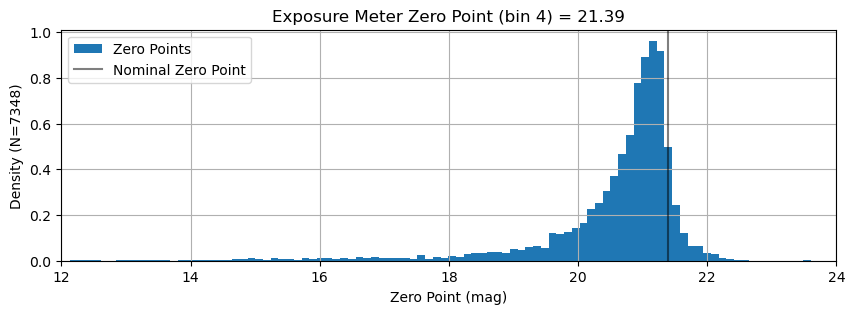

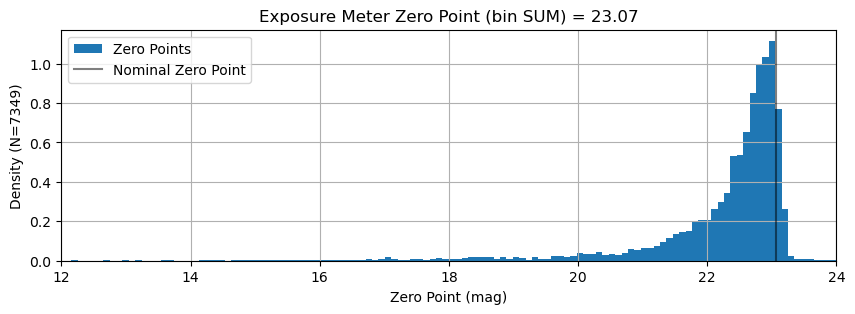

In [9]:
EMZeroPoint = {}
for EMbin in [1, 2, 3, 4, 'SUM']:
    EMZeroPoint[EMbin] = calculate_ExpMeter_zero_point(t, EMbin=EMbin, percentile=90, plot=True)

### Discussion

The distribution of individual zero point values follows roughly what one might expect: a peak at high zero point corresponding to good (cloudless) conditions.  The width of that peak is probably related to the seeing distribution of these observations.  The long tail of zero points at lower values correspond to cloudy nights with poor throughput.

It is notable that the exposure meter's "bin 4" (wavelength of about 810nm) has a stronger tail to very high zero points. It is not clear what is different here, but this is the extreme edge of the exposure meter's wavelength range.

In [10]:
EMZeroPoint

{1: 21.296861833059204,
 2: 21.802875631774594,
 3: 21.73859924329517,
 4: 21.385171098414354,
 'SUM': 23.06521519492087}

## Check for Evolution Over Time

We bin the zero point values by day (MJD) to see if we can discern any time evolution.

/Users/jwalawender/miniforge3/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


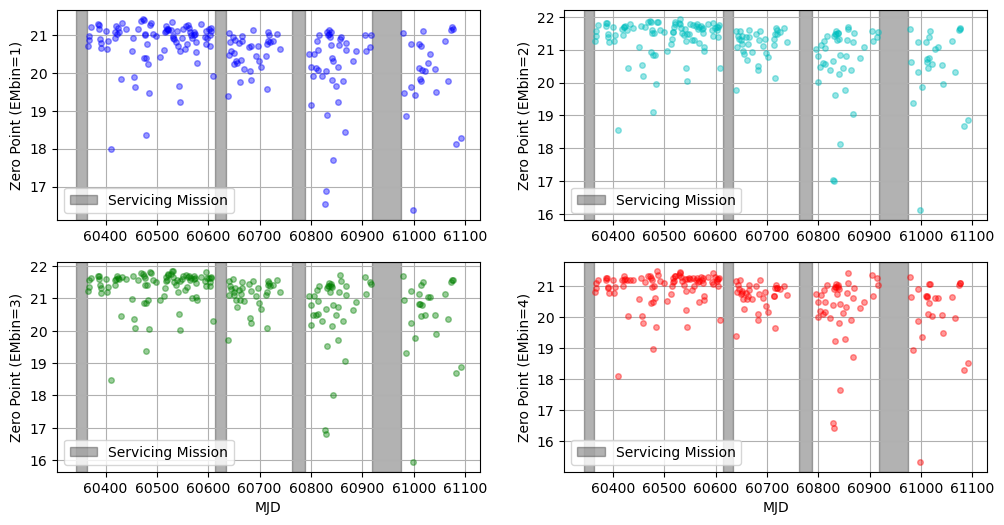

In [11]:
mjd = np.array([int(d) for d in t['MJD-OBS']])

plt.figure(figsize=(12,6))

for EMbin in [1, 2, 3, 4]:
    mask = t[f'EMZP_{EMbin}'].mask
    plt.subplot(2,2,EMbin)
    color = ['b', 'c', 'g', 'r'][EMbin-1]
    for j,day in enumerate(set(mjd)):
        wday = (mjd == day) & ~mask
        if np.sum(np.array(wday, dtype=int)) > 9:
            zp = np.median(t[f'EMZP_{EMbin}'][wday])
            plt.plot(day, zp, f'{color}o', alpha=0.4, ms=4)
    plt.axvspan(SM1start.mjd, SM1end.mjd, color='k', alpha=0.3, label='Servicing Mission')
    plt.axvspan(SM2start.mjd, SM2end.mjd, color='k', alpha=0.3)
    plt.axvspan(SM3start.mjd, SM3end.mjd, color='k', alpha=0.3)
    plt.axvspan(SM4start.mjd, SM4end.mjd, color='k', alpha=0.3)
    plt.ylabel(f'Zero Point (EMbin={EMbin})')
    plt.legend(loc='best')
    # plt.gca().set_xticklabels([])
    if EMbin in [3, 4]:
        plt.xlabel('MJD')
    plt.grid()

plt.show()

### Discussion

There are hints of a time evolution here.  Specifically there appears to be a drop in zero points after the second servicing mission.

Note that data from before the first servicing mission is not shown as the reformatter was realigned during that servicing mission.  Prior to that realignment, the fraction of light sent to the exposure meter was higher.

# Save Results to Disk

In [12]:
t.write('data/Feb2026_withEMZPs.csv', overwrite=True)

In [13]:
EMZPfile = Path('data/ExposureMeterZeroPoints.yaml')
if EMZPfile.exists(): EMZPfile.unlink()
with open(EMZPfile, 'w') as f:
    f.write(yaml.dump(EMZeroPoint))